In [ ]:
import torch
from torch.nn.functional import conv2d
import numpy as np
import matplotlib.pyplot as plt
import imageio

#torch.set_default_device(device='cuda')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

In [ ]:
def createLattices(N_lattices, dim_lattices, up_spins):
    lattices_list = [] # sublistas: modelos [dim1, dim2, dim3, fracción spin up inicial]
    for j in range(0, N_lattices, 1):
        dim_lat = dim_lattices.copy()
        dim_lat.append(up_spins[j])
        lattices_list.append(dim_lat)

    lattices = []
    for dims in lattices_list:
        ups = dims.pop()
        lattice = np.random.choice([1, -1], size = tuple(dims), p=[ups, 1-ups])
        lattices.append(lattice)
    lattices = torch.tensor(np.array(lattices)).to(device)
    lattices = lattices.unsqueeze(1)  # (Nº redes, 1 canal, altura, anchura) para que fucnione conv2d
    
    return lattices

def getEnergyLattice(lattices, J=1): # nos devuevle tensor de shape igual que lattices donde cada elemento es la energía calcualda con sus vecinos
    mask2d = torch.zeros((3, 3), dtype=bool).to(device)
    mask2d[0, 1] = mask2d[2, 1] = mask2d[1, 0] = mask2d[1, 2] = 1
    mask2d = mask2d.unsqueeze(0).unsqueeze(0).to(device) # (1 salida, 1 canal, altura, anchura)
    Etotal = -J*lattices*conv2d(input=lattices.to(torch.float32), weight=mask2d.to(torch.float32), padding='same') #padding para que no se coma el borde
    return Etotal
    
def getEnergyScalar(lattices):
    return getEnergyLattice(lattices).sum(axis=(2, 3)).squeeze()

def getDeltaEnergyLattice(lattices): # resultado de cálculo de la diferencia de energía al cambiar 1 spin
    return -2*getEnergyLattice(lattices)

def MetropolisStep(lattices, betas, J=1):
    # No vamos a cambiar un solo spin a la vez, creamos una malla donde spines separados por 1 átomo se cambien y localmente se decida 
    # si mantener el cambio o no. Solo hay 4 posibels mallas que generar, las que empiecen en el átomo (0, 0), (0, 1), (1, 0) y (1, 1). 
    # Con esas 4 barres todo el espacio.
    i, j = np.random.randint(low = 0, high = 2), np.random.randint(low = 0, high = 2) # 0 o 1
    deltaE = getDeltaEnergyLattice(lattices)[:, :, i::2, j::2] # nos quedamos con las mallas seleccionadas. espacialmente tenemos la mitad de elementos al ahcer esto
    #creamos máscara que aplique metrópolis. de primeras nos quedamos siempre con las variaciones que reducen al energía.
    mask = (deltaE<0) | (deltaE>=0)*(torch.rand(deltaE.shape).to(device) < torch.exp(-betas*deltaE))
    sub_lattice = lattices[:, :, i::2, j::2]
    sub_lattice[mask] *= -1
    lattices[:, :, i::2, j::2] = sub_lattice
    energies = getEnergyScalar(lattices)
    spins = lattices.sum(axis=(-1, -2))/np.prod(lattices.shape[-2:]) #valor medio del spin
    return lattices, energies, spins


def runMetropolis(lattices, steps, T, gif, kB=1):
    N_lattices = lattices.shape[0]
    betas = (1 / (kB * T)) * torch.ones(N_lattices, device=device)
    betas = betas.view(-1, 1, 1, 1)

    lats_list = []
    energies_list = []
    spins_list = []

    for step in range(0, steps, 1):
        lat, ene, spin = MetropolisStep(lattices, betas)
        if step % 10 == 0 and gif==True:
            lats_list.append(lat.detach().cpu())
            del lat
        energies_list.append(ene)
        spins_list.append(spin)
        # if step % 10000 == 0:
        #     print(f'Step: {step}/{steps}')
    return lats_list, energies_list, spins_list


In [ ]:
T = 0.5 # K
kB = 1 # J/K


dim_lattices = [100, 100] # todas las lattices generadas deben tener misma dim para correr en paralelo
up_spins = [0.75, 0.5, 0.25]
steps = 1000
N_lattices = len(up_spins)

lattices = createLattices(N_lattices, dim_lattices, up_spins)
print('Lattices shape: ', lattices.shape)


lats_list, energies_list, spins_list = runMetropolis(lattices, steps, T, gif=False)




In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np


energies_array = torch.stack(energies_list).squeeze().cpu() #shape (steps, N_lattices)
spins_array = torch.stack(spins_list).squeeze().cpu() # shape (steps, N_lattices)

# si hay solo 1 lattice, añadimos dimensión de columnas
if energies_array.dim() == 1:
    energies_array = energies_array.unsqueeze(1)
    spins_array = spins_array.unsqueeze(1)

energies_array = energies_array.numpy()
spins_array = spins_array.numpy()

N_lattices = energies_array.shape[1]
steps = energies_array.shape[0]


fig, axs = plt.subplots(N_lattices, 2, figsize=(12, 4*N_lattices))

# si solo hay 1 lattice, axs no es array 2D lo convertimos
if N_lattices == 1:
    axs = np.expand_dims(axs, axis=0)

for i in range(N_lattices):

    axs[i, 0].plot(np.arange(steps), energies_array[:, i], color='blue')
    axs[i, 0].set_title(f"Lattice {i} - Energía")
    axs[i, 0].set_xlabel("Step")
    axs[i, 0].set_ylabel("Energía")
    axs[i, 0].grid(True)
 
    axs[i, 1].plot(np.arange(steps), spins_array[:, i], color='red')
    axs[i, 1].set_title(f"Lattice {i} - Spin")
    axs[i, 1].set_xlabel("Step")
    axs[i, 1].set_ylabel("Spin")
    axs[i, 1].grid(True)

plt.tight_layout()
plt.show()

# Spin vs temperatura


In [5]:
Ts = np.linspace(1, 3, 30)
dims = [1000, 1000]
ups = [0.25, 0.375, 0.5, 0.625, 0.75]
steps = 1000

lats = createLattices(len(ups), dims, ups)
copies = [lats.clone() for i in range(0, len(Ts))]

list_lats = []
list_energies = []
list_spins = []
counter= 1
for lattices, temperature in zip(copies, Ts):
    lats, energies, spins = runMetropolis(lattices, steps, temperature, gif=False)
    list_lats.append(lats)
    list_energies.append(energies)
    list_spins.append(spins)
    print(f'Counter: {counter}/{len(Ts)} - Settings: {temperature} K')
    counter += 1


Counter: 1/30 - Settings: 1.0 K
Counter: 2/30 - Settings: 1.0689655172413792 K
Counter: 3/30 - Settings: 1.1379310344827587 K
Counter: 4/30 - Settings: 1.206896551724138 K
Counter: 5/30 - Settings: 1.2758620689655173 K
Counter: 6/30 - Settings: 1.3448275862068966 K
Counter: 7/30 - Settings: 1.4137931034482758 K
Counter: 8/30 - Settings: 1.4827586206896552 K
Counter: 9/30 - Settings: 1.5517241379310345 K
Counter: 10/30 - Settings: 1.6206896551724137 K
Counter: 11/30 - Settings: 1.6896551724137931 K
Counter: 12/30 - Settings: 1.7586206896551724 K
Counter: 13/30 - Settings: 1.8275862068965516 K
Counter: 14/30 - Settings: 1.896551724137931 K
Counter: 15/30 - Settings: 1.9655172413793103 K
Counter: 16/30 - Settings: 2.0344827586206895 K
Counter: 17/30 - Settings: 2.103448275862069 K
Counter: 18/30 - Settings: 2.1724137931034484 K
Counter: 19/30 - Settings: 2.2413793103448274 K
Counter: 20/30 - Settings: 2.310344827586207 K
Counter: 21/30 - Settings: 2.3793103448275863 K
Counter: 22/30 - Set

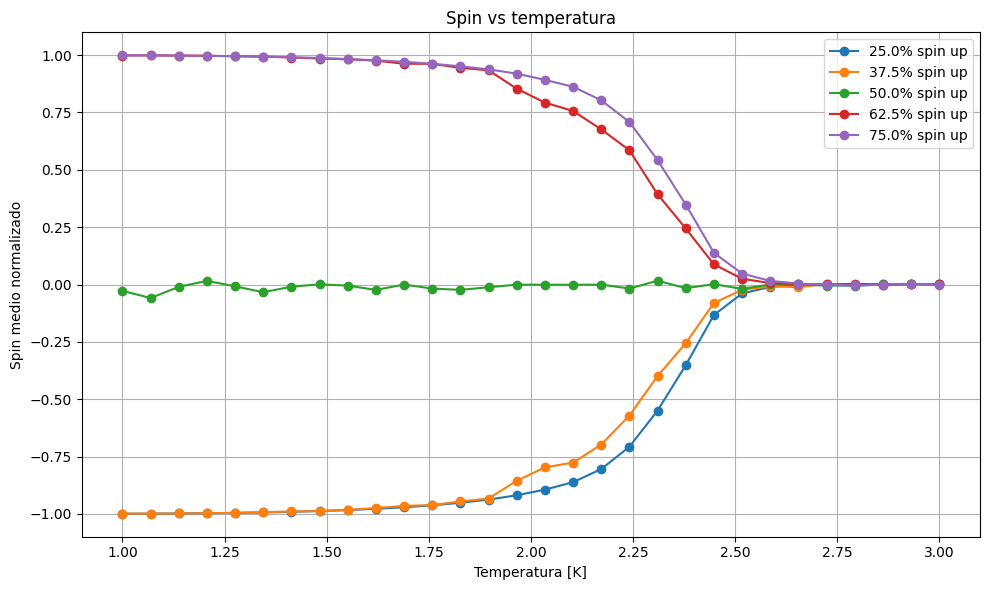

In [6]:
mean_spins = []
for i in range(0, len(Ts)):
    lasts = list_spins[i][-int(0.2*steps):] #hacemos la media del la magnetizacion de lso ultimos 50 steps
    mean = torch.stack(lasts, dim=0).mean(dim=0)
    mean_spins.append(mean)


num_series = mean_spins[0].shape[0]
series_list = []

for i in range(num_series):
    serie = torch.cat([m[i] for m in mean_spins], dim=0) 
    series_list.append(serie)


series_np = [s.cpu().numpy().squeeze() for s in series_list]   # pa que sea 1d

#calculamos los lugares de máxima variación
plt.figure(figsize=(10, 6))

for serie, up in zip(series_np, ups):
    plt.plot(Ts,serie, label=f'{up*100}% spin up', marker = 'o')

    

plt.title('Spin vs temperatura')
plt.xlabel('Temperatura [K]')
plt.ylabel('Spin medio normalizado')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# Crear GIFs

In [7]:
# para crear gifs sin que te explote el ordenador:
Ts_gif = [2]
dims_gif = [1000, 1000]
ups_gif = [0.75]
steps_gif = 10000

lats_gif = createLattices(len(ups_gif), dims_gif, ups_gif)
copies_gif = [lats_gif.clone() for i in range(0, len(Ts_gif))]

list_lats_gif = []
list_energies_gif = []
list_spins_gif = []
counter_gif= 1
for lattices_gif, temperature_gif in zip(copies_gif, Ts_gif):
    lats_gif, energies_gif, spins_gif = runMetropolis(lattices_gif, steps_gif, temperature_gif, gif=True)
    list_lats_gif.append(lats_gif)
    list_energies_gif.append(energies_gif)
    list_spins_gif.append(spins_gif)
    print(f'Counter: {counter_gif}/{len(Ts_gif)} - Settings: {temperature_gif} K')
    counter_gif += 1


frames_gif = [list_lats_gif[0][j][0].cpu().numpy().squeeze() for j in range(len(list_lats_gif[0]))]

processed_frames = []

for f in frames_gif:
    f_uint8 = ((f + 1) / 2 * 255).astype(np.uint8)
    processed_frames.append(f_uint8)

imageio.mimsave("animacion.gif", processed_frames, fps=10)

Counter: 1/1 - Settings: 2 K
